# Urgency Tagging with GRU Model

Mengimplementasikan model **GRU (Gated Recurrent Unit)** untuk klasifikasi tingkat urgensi komplain konsumen: **High**, **Medium**, dan **Low**.

## Alur Pipeline
1. Load dataset ter-lemmatisasi (`cleaned_complaints.csv`)
2. **Undersampling** — penyeimbangan kelas (High = Medium = Low)
3. Pembagian data stratified (Train 70%, Val 15%, Test 15%)
4. **[EDA]** Analisis parameter tokenisasi (`max_words` & `max_len`)
5. Label encoding kelas target
6. Tokenisasi teks & padding sekuens
7. Definisi arsitektur model GRU
8. Pelatihan dengan Early Stopping & ModelCheckpoint
9. Visualisasi Loss & Accuracy
10. Evaluasi (Classification Report & Confusion Matrix)
11. Simpan artefak model ke `models/`

## Tahap 1 — Setup: Import Library & Konfigurasi Environment

- Deteksi lingkungan (Google Colab / lokal) dan atur `PROJECT_ROOT`
- Import seluruh library yang dibutuhkan
- Set global random seed (`SEED=42`) untuk reprodusibilitas

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import random

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
    os.chdir(PROJECT_ROOT)
else:
    notebook_dir = os.getcwd()
    PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..')) if os.path.basename(notebook_dir) == 'notebooks' else notebook_dir
    os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.features import split_data, extract_lstm_sequences

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Project root: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
Project root: /content/drive/MyDrive/lentera-ml-research


## Tahap 2 — Data: Load, Undersample & Split

### 1. Load dan Validasi Dataset

- Baca `cleaned_complaints.csv` dari `data/processed/`
- Hapus baris dengan nilai kosong pada kolom `Cleaned_Narrative` atau `Urgency`

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])

print(f"Shape dataset: {df.shape}")
print(df['Urgency'].value_counts())

Shape dataset: (121485, 3)
Urgency
High      52471
Medium    49583
Low       19431
Name: count, dtype: int64


### 2. Undersampling — Penyeimbangan Kelas

- Sampel setiap kelas ke ukuran kelas minoritas (`min_class_size`)
- Semua kelas menjadi **seimbang** → menggantikan kebutuhan *class weight*
- `random_state=SEED` untuk reprodusibilitas

In [3]:
min_class_size = df['Urgency'].value_counts().min()

df_high   = df[df['Urgency'] == 'High']
df_medium = df[df['Urgency'] == 'Medium']
df_low    = df[df['Urgency'] == 'Low']

if len(df_high) > min_class_size:
    df_high = df_high.sample(min_class_size, random_state=SEED)
if len(df_medium) > min_class_size:
    df_medium = df_medium.sample(min_class_size, random_state=SEED)
if len(df_low) > min_class_size:
    df_low = df_low.sample(min_class_size, random_state=SEED)

df = pd.concat([df_high, df_medium, df_low])
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Ukuran per kelas (min_class_size): {min_class_size:,}")
print("\nDistribusi kelas setelah undersampling:")
print(df['Urgency'].value_counts())

Ukuran per kelas (min_class_size): 19,431

Distribusi kelas setelah undersampling:
Urgency
High      19431
Medium    19431
Low       19431
Name: count, dtype: int64


### 3. Pembagian Data (Data Splitting)

- Split stratified: **Train 70%**, **Validation 15%**, **Test 15%**
- Menggunakan `split_data` dari `src.features` untuk konsistensi lintas notebook

In [4]:
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

Train size: 40805, Val size: 8744, Test size: 8744


## Tahap 3 — EDA Parameter Tokenisasi

### 4. Analisis Parameter Tokenisasi

Menentukan `max_words` dan `max_len` secara empiris dari data latih — bukan nilai hardcoded.

- **`max_words`**: terlalu besar → boros memori; terlalu kecil → banyak kata OOV
- **`max_len`**: terlalu besar → padding berlebihan; terlalu kecil → konteks terpotong

> ⚠️ Analisis dilakukan **hanya pada `df_train`** untuk menghindari data leakage.

In [5]:
train_token_lengths = df_train['Cleaned_Narrative'].astype(str).apply(lambda x: len(x.split()))

print(f"Jumlah sampel : {len(train_token_lengths):,}")
print(f"Min           : {train_token_lengths.min()} token")
print(f"Mean          : {train_token_lengths.mean():.1f} token")
print(f"Median (P50)  : {train_token_lengths.median():.0f} token")
print(f"P75           : {train_token_lengths.quantile(0.75):.0f} token")
print(f"P90           : {train_token_lengths.quantile(0.90):.0f} token")
print(f"P95           : {train_token_lengths.quantile(0.95):.0f} token")
print(f"P99           : {train_token_lengths.quantile(0.99):.0f} token")
print(f"Max           : {train_token_lengths.max():,} token")

Jumlah sampel : 40,805
Min           : 1 token
Mean          : 91.1 token
Median (P50)  : 67 token
P75           : 119 token
P90           : 188 token
P95           : 246 token
P99           : 436 token
Max           : 2,006 token


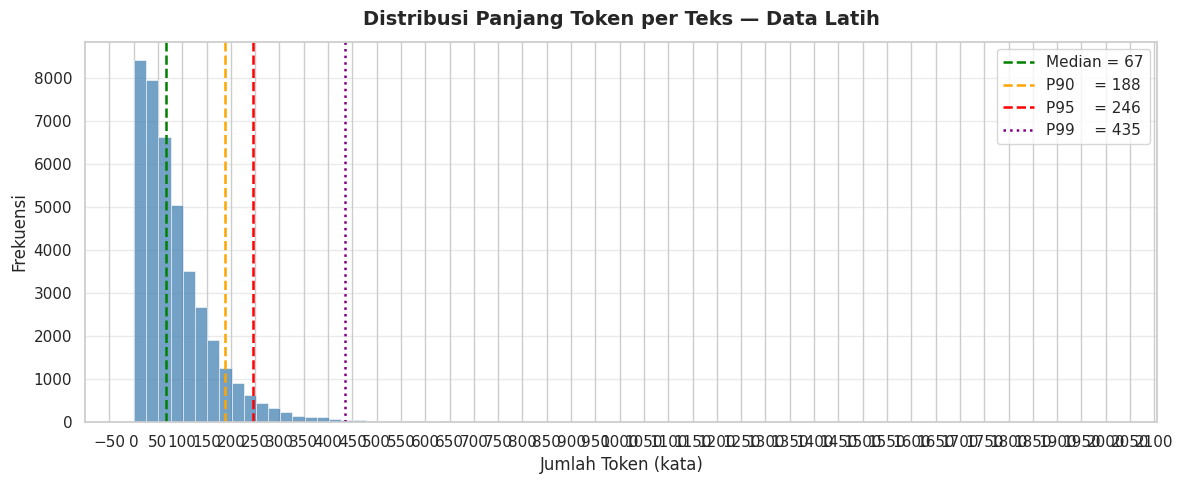

In [6]:
p90 = int(train_token_lengths.quantile(0.90))
p95 = int(train_token_lengths.quantile(0.95))
p99 = int(train_token_lengths.quantile(0.99))
median_len = int(train_token_lengths.median())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(train_token_lengths, bins=80, color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(median_len, color='green',  linestyle='--', linewidth=1.8, label=f'Median = {median_len}')
ax.axvline(p90,        color='orange', linestyle='--', linewidth=1.8, label=f'P90    = {p90}')
ax.axvline(p95,        color='red',    linestyle='--', linewidth=1.8, label=f'P95    = {p95}')
ax.axvline(p99,        color='purple', linestyle=':',  linewidth=1.8, label=f'P99    = {p99}')
ax.set_title('Distribusi Panjang Token per Teks — Data Latih', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Token (kata)', fontsize=12)
ax.set_ylabel('Frekuensi', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [7]:
_probe_tokenizer = Tokenizer(oov_token="<OOV>")
_probe_tokenizer.fit_on_texts(df_train['Cleaned_Narrative'])

actual_vocab_size = len(_probe_tokenizer.word_index)
word_counts = sorted(_probe_tokenizer.word_counts.values(), reverse=True)
total_words = len(word_counts)
total_token_count = sum(word_counts)

print(f"Vocabulary aktual (data latih): {actual_vocab_size:,} kata unik\n")
print(f"{'max_words':>10}  {'Coverage (%)':>14}  {'Kata Diabaikan':>16}  {'Keputusan':>12}")
print("-" * 58)
for threshold in [3000, 5000, 8000, 10000, 12000, 15000, 20000]:
    if threshold >= total_words:
        coverage, ignored = 100.0, 0
    else:
        coverage = sum(word_counts[:threshold]) / total_token_count * 100
        ignored = total_words - threshold
    verdict = "✅ Sangat baik" if coverage >= 99.0 else "✅ Baik" if coverage >= 97.0 else "⚠️  Cukup" if coverage >= 95.0 else "❌ Kurang"
    print(f"{threshold:>10,}  {coverage:>13.2f}%  {ignored:>16,}  {verdict:>12}")

Vocabulary aktual (data latih): 23,426 kata unik

 max_words    Coverage (%)    Kata Diabaikan     Keputusan
----------------------------------------------------------
     3,000          97.09%            20,425        ✅ Baik
     5,000          98.68%            18,425        ✅ Baik
     8,000          99.36%            15,425  ✅ Sangat baik
    10,000          99.55%            13,425  ✅ Sangat baik
    12,000          99.67%            11,425  ✅ Sangat baik
    15,000          99.77%             8,425  ✅ Sangat baik
    20,000          99.91%             3,425  ✅ Sangat baik


In [8]:
p95_raw = train_token_lengths.quantile(0.95)
FINAL_MAX_LEN = int(np.ceil(p95_raw / 25) * 25)

FINAL_MAX_WORDS = None
for threshold in range(1000, actual_vocab_size + 1, 500):
    if sum(word_counts[:threshold]) / total_token_count >= 0.98:
        FINAL_MAX_WORDS = threshold
        break

if FINAL_MAX_WORDS is None:
    FINAL_MAX_WORDS = actual_vocab_size
FINAL_MAX_WORDS = min(FINAL_MAX_WORDS, 20000)

print(f"FINAL max_words = {FINAL_MAX_WORDS:,}  (coverage ≥ 98% token)")
print(f"FINAL max_len   = {FINAL_MAX_LEN}     (P95={p95_raw:.0f}, dibulatkan ke kelipatan 25)")
print(f"Teks terpotong  = {(train_token_lengths > FINAL_MAX_LEN).mean()*100:.1f}%")

FINAL max_words = 4,000  (coverage ≥ 98% token)
FINAL max_len   = 250     (P95=246, dibulatkan ke kelipatan 25)
Teks terpotong  = 4.7%


## Tahap 4 — Preprocessing: Encoding & Tokenisasi

### 5. Label Encoding Target

- Encode label kategori (`High`, `Medium`, `Low`) menjadi integer menggunakan `LabelEncoder`
- `fit` dilakukan pada data train; `transform` pada val dan test

In [9]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(df_train['Urgency'])
y_val_encoded   = label_encoder.transform(df_val['Urgency'])
y_test_encoded  = label_encoder.transform(df_test['Urgency'])

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Pemetaan kelas target:", class_mapping)

Pemetaan kelas target: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


### 6. Tokenisasi dan Padding Sekuens

- Ubah teks menjadi sekuens integer menggunakan `extract_lstm_sequences`
- Parameter `max_words` dan `max_len` berasal dari hasil EDA (Tahap 3)

In [13]:
X_train_pad, X_val_pad, X_test_pad, tokenizer = extract_lstm_sequences(
    df_train['Cleaned_Narrative'],
    df_val['Cleaned_Narrative'],
    df_test['Cleaned_Narrative'],
    max_words=FINAL_MAX_WORDS,
    max_len=FINAL_MAX_LEN
)

print(f"X_train_pad : {X_train_pad.shape}")
print(f"X_val_pad   : {X_val_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")
print(f"Vocabulary efektif: {len(tokenizer.word_index):,} kata")

X_train_pad : (40805, 250)
X_val_pad   : (8744, 250)
X_test_pad  : (8744, 250)
Vocabulary efektif: 23,426 kata


## Tahap 5 — Model: Definisi, Training & Evaluasi

### 7. Definisi Arsitektur Model GRU

Arsitektur sekuensial dengan lapisan:
- **Embedding** (64 dim): konversi integer → vektor padat
- **Bidirectional GRU** (64 unit): menangkap konteks dari dua arah; 2 gate (Reset & Update), lebih ringan dari LSTM
- **Dense** (32 unit, ReLU + L2 regularisasi): representasi laten
- **Dropout** (0.5): regularisasi untuk mencegah overfitting
- **Output** (3 unit, Softmax): distribusi probabilitas per kelas

| Komponen | GRU (notebook ini) | LSTM |
|----------|--------------------|------|
| Layer RNN | `Bidirectional(GRU(64))` | `Bidirectional(LSTM(128))` |
| Gate | 2 | 3 |
| State | Hidden state | Hidden state + Cell state |
| ~Parameter | 198K | 230K |

In [14]:
vocab_size    = FINAL_MAX_WORDS
embedding_dim = 64
max_len       = FINAL_MAX_LEN
num_classes   = len(class_mapping)

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    Bidirectional(GRU(64, dropout=0.4, recurrent_dropout=0)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 64)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,147 (1.18 MB)

 Trainable params: 310,147 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

### 8. Pelatihan Model

- **Epochs**: 50 (epochs besar + Early Stopping adalah best practice — biarkan model konvergen)
- **Early Stopping**: berhenti jika `val_loss` tidak membaik selama **7 epoch** berturut-turut, kembalikan bobot terbaik
- **ModelCheckpoint**: simpan model terbaik otomatis berdasarkan `val_loss`
- **ReduceLROnPlateau**: menurunkan *learning rate* sebesar 50% jika `val_loss` stagnan selama 3 epoch

> Karena kelas sudah seimbang via undersampling, `class_weight` tidak digunakan.

In [15]:
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'gru_urgency_model.keras')
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5874 - loss: 1.0177
Epoch 1: val_loss improved from None to 0.50744, saving model to /content/drive/MyDrive/lentera-ml-research/models/gru_urgency_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lentera-ml-research/models/gru_urgency_model.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.7061 - loss: 0.7594 - val_accuracy: 0.8081 - val_loss: 0.5074
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8092 - loss: 0.5224
Epoch 2: val_loss improved from 0.50744 to 0.48840, saving model to /content/drive/MyDrive/lentera-ml-research/models/gru_urgency_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lentera-ml-research/models/gru_urgency_model.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.8147 - loss: 0.5124 - val_accuracy: 0.8169 - val_loss: 0.4884
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8262 - loss: 0.4788
Ep

### 9. Visualisasi Riwayat Pelatihan

- Plot kurva **Loss** dan **Accuracy** untuk train vs validation
- Berguna untuk mendeteksi gejala *underfitting* atau *overfitting*

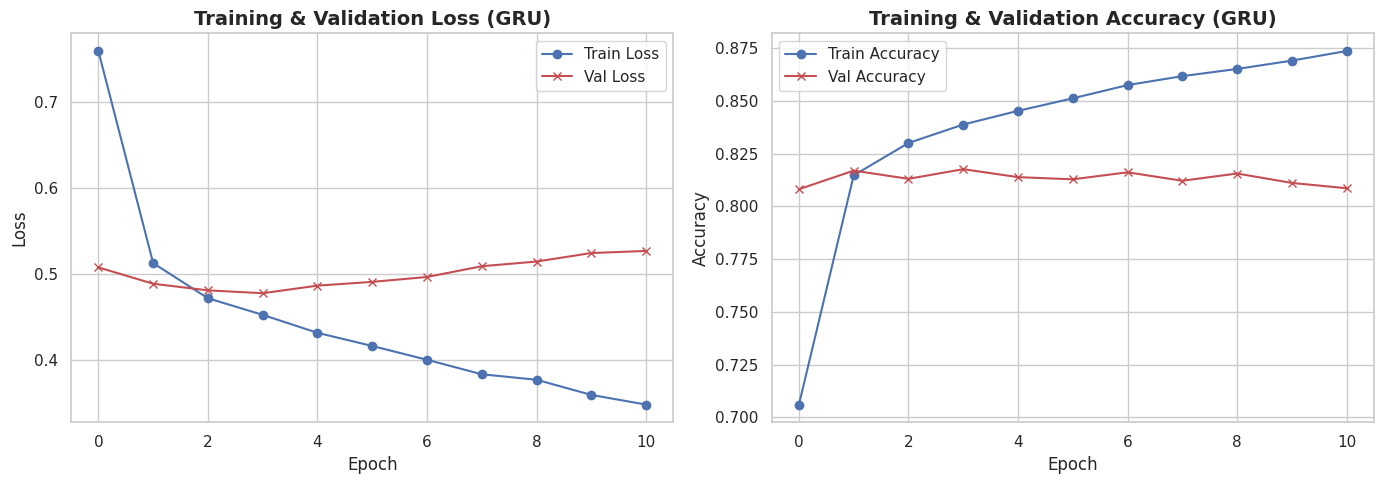

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='b', marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='r', marker='x')
axes[0].set_title('Training & Validation Loss (GRU)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='b', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='r', marker='x')
axes[1].set_title('Training & Validation Accuracy (GRU)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'models', 'gru_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10. Evaluasi Model

- Prediksi pada **test set** (data yang belum pernah dilihat model)
- **Classification Report**: Precision, Recall, F1-Score per kelas
- **Confusion Matrix**: visualisasi distribusi prediksi vs aktual

In [17]:
y_pred_proba = model.predict(X_test_pad, batch_size=64)
y_pred = np.argmax(y_pred_proba, axis=1)

test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded, batch_size=64, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")

print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Test Loss    : 0.4828
Test Accuracy: 0.8171 (81.71%)

              precision    recall  f1-score   support

        High       0.92      0.84      0.88      2914
         Low       0.77      0.82      0.79      2915
      Medium       0.77      0.79      0.78      2915

    accuracy                           0.82      8744
   macro avg       0.82      0.82      0.82      8744
weighted avg       0.82      0.82      0.82      8744



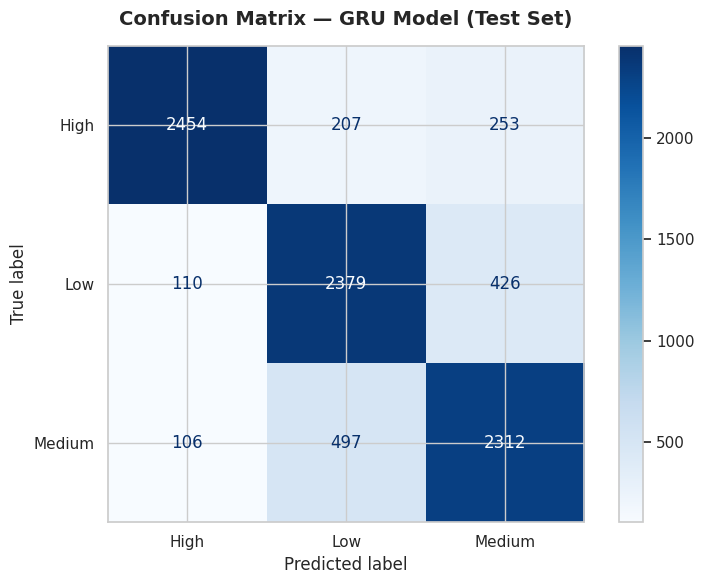

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — GRU Model (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'models', 'gru_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## Tahap 6 — Simpan Artefak

### 11. Simpan Tokenizer & Label Encoder

- Tokenizer dan label encoder disimpan bersama model agar dapat digunakan kembali saat **inferensi**
- Format: `.pkl` (pickle) untuk tokenizer dan label encoder; `.keras` untuk model

In [19]:
TOKENIZER_SAVE_PATH     = os.path.join(PROJECT_ROOT, 'models', 'gru_tokenizer.pkl')
LABEL_ENCODER_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'gru_label_encoder.pkl')

with open(TOKENIZER_SAVE_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)

with open(LABEL_ENCODER_SAVE_PATH, 'wb') as f:
    pickle.dump(label_encoder, f)

print("Artefak tersimpan:")
print(f"  Model       : models/gru_urgency_model.keras")
print(f"  Tokenizer   : models/gru_tokenizer.pkl")
print(f"  LabelEncoder: models/gru_label_encoder.pkl")
print(f"  Plot Loss   : models/gru_training_history.png")
print(f"  Plot CM     : models/gru_confusion_matrix.png")
print(f"\nParameter tokenisasi: max_words={FINAL_MAX_WORDS:,}, max_len={FINAL_MAX_LEN}")

Artefak tersimpan:
  Model       : models/gru_urgency_model.keras
  Tokenizer   : models/gru_tokenizer.pkl
  LabelEncoder: models/gru_label_encoder.pkl
  Plot Loss   : models/gru_training_history.png
  Plot CM     : models/gru_confusion_matrix.png

Parameter tokenisasi: max_words=4,000, max_len=250
